In [117]:
np.exp(-0.0001)

np.float64(0.9999000049998333)

In [157]:
rng = np.random.default_rng()
rng.beta(np.exp(-0.5), np.exp(0.8), size=10)

array([0.35062905, 0.01401763, 0.59694823, 0.25035989, 0.01229533,
       0.22625343, 0.04998769, 0.03249069, 0.24830838, 0.17862494])

In [28]:
import numpy as np
from scipy.stats import beta
from scipy.special import digamma, polygamma
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution
from GASModels.distributions.za_gb2_log_link import ZAGB2LogLinkDistribution


# ==============================
# GB2 utilities
# ==============================
def gb2_rvs(phi, gamma, xi, zeta, size=1, rng=None):
    """
    Generate random variables consistent with GB2LogLinkDistribution.
    """
    if rng is None:
        rng = np.random.default_rng()

    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    u = rng.beta(a, b, size=size)
    z = u / (1 - u)
    y = sigma * z ** (1 / p)

    return y


# ==============================
# Trigonometric seasonal update
# ==============================

def update_trigonometric(components, score, t):
    harmonics = components["harmonics"]
    period = components["period"]

    for i in range(len(components["gamma_"])):
        for j in range(harmonics):
            lambda_ = 2 * np.pi * (j + 1) / period

            g_prev = components["gamma_"][i][j][t]
            gs_prev = components["gamma_star"][i][j][t]
            kg = components["kg"][i]

            gamma_ = (
                np.cos(lambda_) * g_prev
                + np.sin(lambda_) * gs_prev
                + score * kg
            )

            gamma_star = (
                np.cos(lambda_) * gs_prev
                - np.sin(lambda_) * g_prev
                + score * kg
            )

            components["gamma_"][i][j][t + 1] = gamma_
            components["gamma_star"][i][j][t + 1] = gamma_star

    return components


def compute_gamma_sum(components, t):
    total = 0.0
    for i in range(len(components["gamma_"])):
        total += np.sum(components["gamma_"][i][:, t])
    return total


# ==============================
# GAS-GB2 Simulation
# ==============================

def simulate_gas_gb2(
    T=500,
    mu_init=0.0,
    gamma_init=None,
    gamma_star_init=None,
    alpha=0.95,
    kappa_mu=0.10,
    c=0.0,
    gamma=2.0,
    xi=0.0,
    zeta=0.0,
    harmonics=0,
    period=252,
    kg=0.05,
    seed=123
):
    
    distribution = GB2LogLinkDistribution()
    rng = np.random.default_rng(seed)

    # Storage
    mu = np.zeros(T + 1)
    phi = np.zeros(T)
    y = np.zeros(T)
    score = np.zeros(T)

    mu[0] = mu_init

    # Seasonal components
    components = {
        "harmonics": harmonics,
        "period": period,
        "gamma_": [np.zeros((harmonics, T + 1))],
        "gamma_star": [np.zeros((harmonics, T + 1))],
        "kg": [kg]
    }

    if gamma_init is not None:
        components["gamma_"][0][:, 0] = gamma_init

    if gamma_star_init is not None:
        components["gamma_star"][0][:, 0] = gamma_star_init

    # Simulation loop
    for t in range(T):

        gamma_t = compute_gamma_sum(components, t)
        phi[t] = mu[t] + gamma_t

        y[t] = gb2_rvs(phi[t], gamma, xi, zeta, rng=rng)[0]
        score[t] = distribution.score(y[t], phi =phi[t], gamma = gamma, xi = xi, zeta = zeta)[0]

        mu[t + 1] = c + alpha * mu[t] + kappa_mu * score[t]

        components = update_trigonometric(components, score[t], t)

    return {
        "y": y,
        "phi": phi,
        "mu": mu[:-1],
        "score": score,
        "gamma_components": components
    }


# ==============================
# Example usage
# ==============================

if __name__ == "__main__":


    T = 730

    gamma_init = np.zeros(0)
    gamma_star_init = np.zeros(0)

    sim = simulate_gas_gb2(
        T=3650,

        # Initial conditions
        mu_init=4.0,                   # raises baseline scale
        gamma_init=gamma_init,
        gamma_star_init=gamma_star_init,

        # GAS dynamics
        alpha=0.75,                    # slightly less persistent
        kappa_mu=0.2,                 # moderate feedback (not explosive)
        c=1.0,                        # gentle upward drift

        # GB2 shape (moderately heavy tails, finite variance)
        gamma=0.01,                     # controls overall dispersion
        xi=1.0,                        # left shape
        zeta=2.0,                      # right shape (finite variance)

        # Trigonometric seasonality
        harmonics=0,
        period=365.25,
        kg=0.00,                       # restores seasonal amplitude

        seed=42
    )

    y = sim["y"]

    print("max y:", y.max())
    print("mean y:", y.mean())
    print("95% quantile:", np.quantile(y, 0.95))
    print("99% quantile:", np.quantile(y, 0.99))

    phi = sim["phi"]


max y: 361.02040759451484
mean y: 24.036321336084917
95% quantile: 65.82182116437791
99% quantile: 122.77024307747399


In [164]:
np.exp(-2.0)

np.float64(0.1353352832366127)

In [165]:
y[0]

np.float64(115.28149248468884)

In [29]:
y

array([16.85659082, 18.75440144, 28.81677314, ..., 11.61314117,
       10.22332648, 16.52116668], shape=(3650,))

<Axes: >

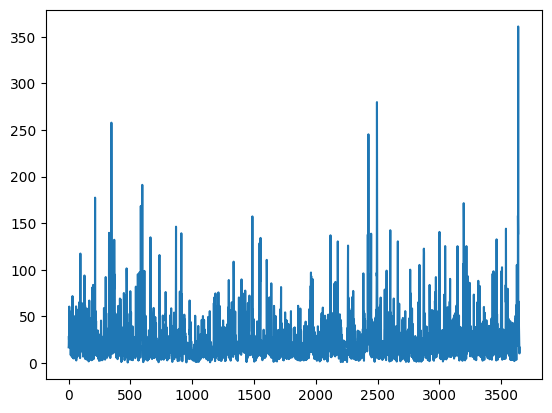

In [30]:
import seaborn as sns

sns.lineplot(y)
# sns.lineplot(x=np.arange(T), y=phi, label="phi")
# sns.lineplot(x=np.arange(T), y=sim["mu"], label="mu")
# sns.lineplot(x=np.arange(T), y=sim["score"], label="score")

(array([ 9., 48., 82., 88., 98., 98., 72., 55., 44., 37., 19., 24., 15.,
         7.,  5.,  2.,  6.,  5.,  4.,  2.,  0.,  2.,  0.,  2.,  1.,  0.,
         2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([  1.07023712,   5.84764631,  10.62505549,  15.40246467,
         20.17987385,  24.95728304,  29.73469222,  34.5121014 ,
         39.28951059,  44.06691977,  48.84432895,  53.62173814,
         58.39914732,  63.1765565 ,  67.95396569,  72.73137487,
         77.50878405,  82.28619323,  87.06360242,  91.8410116 ,
         96.61842078, 101.39582997, 106.17323915, 110.95064833,
        115.72805752, 120.5054667 , 125.28287588, 

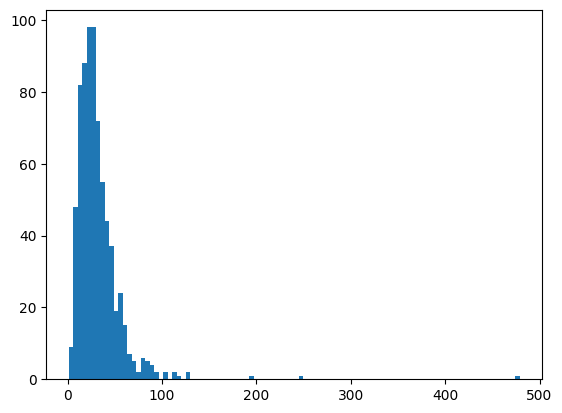

In [248]:
plt.hist(y, bins=100)

In [65]:
from scipy.special import digamma, polygamma, beta
gamma = 1.0
xi = 1.0
zeta = 2.2
beta(np.exp(xi) + np.exp(gamma), np.exp(zeta) - np.exp(gamma))/ beta(np.exp(xi), np.exp(zeta))

np.float64(0.1447940336007477)

In [66]:
np.exp(5) * 0.14

np.float64(20.777842274360726)

In [8]:
y[y > 1000]

array([4035.14865868, 2997.15960247, 1275.68019072, 3103.41341777,
       4665.75093326, 3782.30130811])

## Fit

In [ ]:
import numpy as np
from scipy.special import betaln
from scipy.stats import beta
from scipy.optimize import minimize

def iterate(
    mu0,
    gamma0,
    gamma_star0,
    alpha,
    kappa_mu,
    c,
    gamma,
    xi,
    zeta,
    harmonics,
    period,
    T,
    y=None,
    mode="loglik"
):
    """
    GAS recursion with trigonometric seasonality.

    If mode == "loglik":
        returns -loglik (for optimizer)

    If mode == "filter":
        returns dict with states and scores
    """

    dist = GB2LogLinkDistribution()
    
    if gamma < 0:
        return 1e12
    if zeta <= 2*gamma + 0.2:
        return 1e12
    if not (0 <= alpha < 1):
        return 1e12

    # --- allocate ---
    mu = np.zeros(T + 1)
    phi = np.zeros(T)
    score = np.zeros(T)
    
    km = kappa_mu
    kg = 0.0
    mu[0] = mu0
    gamma_ = gamma0.copy()          # shape: (harmonics,)
    gamma_star = gamma_star0.copy() # shape: (harmonics,)

    loglik = 0.0

    # --- initial state ---
    phi[0] = mu[0] #+ np.sum(gamma_)

    # --- main recursion ---
    for t in range(T):

        if t > 0:
            phi[t] = mu[t]# + np.sum(gamma_)

        # ---------- LOG-LIKELIHOOD ----------
        if mode == "loglik":

            if y is None:
                raise ValueError("y must be provided when mode='loglik'")

            if y[t] <= 0 or not np.isfinite(phi[t]):
                return 1e12   # hard penalty for optimizer

            ll = dist.logpdf(
                y[t],
                phi=phi[t],
                gamma=gamma,
                xi=xi,
                zeta=zeta
            )

            if not np.isfinite(ll):
                return 1e12

            loglik += ll

        # ---------- SCORE ----------
        s = dist.score(
            y[t],
            phi=phi[t],
            gamma=gamma,
            xi=xi,
            zeta=zeta
        )

        score[t] = s[0]   # only φ-score drives GAS

        # ---------- GAS μ UPDATE ----------
        mu[t + 1] = c + alpha * mu[t] + km * score[t]

        # ---------- TRIGONOMETRIC γ UPDATE ----------
        for j in range(harmonics):

            lam = 2 * np.pi * (j + 1) / period

            g_prev = gamma_[j]
            gs_prev = gamma_star[j]

            gamma_new = (
                np.cos(lam) * g_prev
                + np.sin(lam) * gs_prev
                + kg * score[t]
            )

            gamma_star_new = (
                np.cos(lam) * gs_prev
                - np.sin(lam) * g_prev
                + kg * score[t]
            )

            gamma_[j] = gamma_new
            gamma_star[j] = gamma_star_new

    # --- return modes ---
    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "mu": mu[:-1],
            "gamma": gamma_,
            "gamma_star": gamma_star,
            "score": score,
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")

        

In [32]:
def objective(theta, y, harmonics=0, period=365):

    mu0, c, alpha, kappa_mu, gamma, xi, zeta = theta

    T = len(y)

    gamma0 = np.zeros(harmonics)
    gamma_star0 = np.zeros(harmonics)

    return iterate(
        mu0=mu0,
        gamma0=gamma0,
        gamma_star0=gamma_star0,
        alpha=alpha,
        kappa_mu=kappa_mu,
        c=c,
        gamma=gamma,
        xi=xi,
        zeta=zeta,
        harmonics=harmonics,
        period=period,
        T=T,
        y=y,
        mode="loglik"
    )


In [33]:
from scipy.optimize import minimize

# -----------------------
# Observed data (example)
# -----------------------
# y = your observed series (positive, length T)
# For demo purposes only:
# y = np.abs(np.random.randn(1000)) + 1e-3

T = len(y)
harmonics = 10
period = 365

# -----------------------
# Initial guess (near your DGP)
# -----------------------
theta0 = np.array([
    np.log(np.mean(y)),      # mu0
    1.0,      # c
    0.65,     # alpha
    0.1,     # kappa_mu
    0.01,      # gamma
    1.0,      # xi
    2.0       # zeta
])


# -----------------------
# Parameter bounds
# -----------------------
bounds = [
    (-1.0, 10.0),       # mu0
    (-10.0, 10.0),       # c
    (0.00, 0.995),     # alpha
    (1e-4, 0.5),      # kappa_mu
    (0.0, 1.0),        # gamma
    (0.1, 3.0),        # xi
    (1.2, 4.0)         # zeta > 2*gamma
]


# -----------------------
# Run optimizer
# -----------------------
res = minimize(
    objective,
    theta0,
    args=(y, harmonics, period),
    method="L-BFGS-B",
    bounds=bounds,
    options={
        'gtol': 1e-3,
        'maxiter': 100,
        'disp': True
        }
)

# -----------------------
# Results
# -----------------------
print("Converged:", res.success)
print("Message:", res.message)
print("NegLogLik:", res.fun)



C:\Users\ilang\AppData\Local\Temp\ipykernel_11564\4044235268.py:45: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: overflow encountered in exp
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: divide by zero encountered in log
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:33: RuntimeWarning: overflow encountered in exp
  - (np.exp(xi) + np.exp(zeta)) * (1 + (y / np.exp(phi)) ** (np.exp(-gamma)))


Converged: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
NegLogLik: 32056.674206172534


In [34]:
param_names = ["mu0", "c", "alpha", "kappa_mu", "gamma", "xi", "zeta"]
for name, val in zip(param_names, res.x):
    print(f"{name:12s}: {val: .5f}")


mu0         :  3.41077
c           :  1.13485
alpha       :  0.77778
kappa_mu    :  0.50000
gamma       :  0.00000
xi          :  0.10000
zeta        :  1.20000


In [45]:
gamma_res = res.x[4]
xi_res = res.x[5]
zeta_res = res.x[6]

phi_hat = iterate(
    mu0=res.x[0],
    gamma0=np.zeros(harmonics),
    gamma_star0=np.zeros(harmonics),
    alpha=res.x[2],
    kappa_mu=res.x[3],
    c=res.x[1],
    gamma=gamma,
    xi=xi,
    zeta=zeta,
    harmonics=harmonics,
    period=period,
    T=T,
    y=y,
    mode="filter"
)

phi_hat = phi_hat['phi']


In [11]:
#Initial conditions
mu_init=4.0                   # raises baseline scale
# gamma_init=gamma_init,
# gamma_star_init=gamma_star_init,

# GAS dynamics
alpha=0.75                    # slightly less persistent
kappa_mu=0.2                 # moderate feedback (not explosive)
c=1.0                        # gentle upward drift

# GB2 shape (moderately heavy tails, finite variance)
gamma=-0.02                     # controls overall dispersion
xi=1.0                        # left shape
zeta=2.0                      # right shape (finite variance)

# Trigonometric seasonality
harmonics=10
period=365.25
kg=0.00  

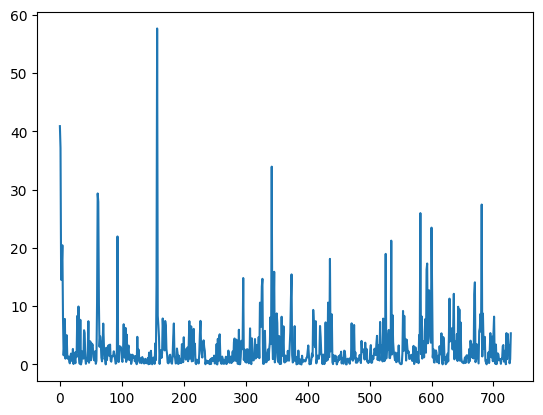

In [240]:
plt.plot(y[1:])

In [176]:
res['x']

array([ 2.00000000e+00,  1.00000000e-01,  9.87180150e-01,  3.64602285e-01,
        1.00000000e-04, -1.00000000e+00,  0.00000000e+00,  2.00000000e+00])

In [184]:
len(y)

730

In [48]:
out = iterate(
    mu0=mu0_res,
    gamma0=np.zeros(harmonics),
    gamma_star0=np.zeros(harmonics),
    alpha=alpha_res,
    kappa_mu=kappa_mu_res,
    c=c_res,
    gamma=gamma_res,
    xi=xi_res,
    zeta=zeta_res,
    harmonics=harmonics,
    period=period,
    T=len(y),
    y=y,
    mode="filter"
)

phi_hat = out["phi"]

dist = GB2LogLinkDistribution()
pit = np.array([
    cdf(y[t], phi=sim['phi'][t],
             gamma=gamma, xi=xi, zeta=zeta)
    for t in range(len(y))
])

In [46]:
mu0_res = res.x[0]
c_res = res.x[1]
alpha_res = res.x[2]
kappa_mu_res = res.x[3]
gamma_res = res.x[4]
xi_res = res.x[5]
zeta_res = res.x[6]

In [48]:
from scipy.special import betainc
import numpy as np

def gb2_cdf(y, phi, gamma, xi, zeta):

    a = np.exp(xi)          # matches beta(exp(xi), exp(zeta))
    b = np.exp(zeta)
    p = np.exp(-gamma)      # matches power in logpdf
    sigma = np.exp(phi)

    z = (y / sigma) ** p
    u = z / (1 + z)
    u = np.clip(u, 1e-12, 1 - 1e-12)

    return betainc(a, b, u)

In [49]:
dist = GB2LogLinkDistribution()
pit = np.array([
    gb2_cdf(y[t], phi=phi_hat[t],
             gamma=gamma_res, xi=xi_res, zeta=zeta_res)
    for t in range(len(y))
])

In [ ]:
phi_hat = out["phi"]

dist = GB2LogLinkDistribution()
pit = np.array([
    cdf(y[t], phi=sim['phi'][t],
             gamma=gamma_res, xi=xi_res, zeta=zeta_res)
    for t in range(len(y))
])

In [40]:
import numpy as np
from scipy.special import betainc

def cdf(y, phi, gamma, xi, zeta):

    a = np.exp(-gamma)
    p = np.exp(xi)
    q = np.exp(zeta)
    b = np.exp(phi)

    z = (y / b) ** p
    u = z / (1 + z)

    return betainc(a, q, u)

In [228]:
y[100], phi_hat[100]

(np.float64(2.618357985685606), np.float64(3.229454124132287))

array([7.        , 6.31485954, 5.81408152, 5.56399663, 5.28846361,
       5.18683349, 5.18212199, 5.01045763, 4.67405632, 4.58845424,
       4.71393193, 4.44316684, 4.49533392, 4.58433208, 4.41000322,
       4.27210379, 4.24591538, 4.12216841, 3.89910697, 4.03154478,
       4.16050093, 4.17510308, 4.06299378, 4.249136  , 3.88951186,
       4.06907639, 4.0898525 , 3.88006853, 4.08348415, 4.11495974,
       4.48062646, 4.40575361, 4.64806488, 4.4263854 , 4.02748907,
       4.35997211, 3.81820758, 3.73906305, 3.94180999, 3.99058665,
       4.00055164, 4.32816219, 4.47317956, 4.29537281, 3.93750838,
       3.91345502, 3.88144906, 4.09567151, 4.43233945, 4.10886059,
       4.11328831, 4.30937144, 4.15139611, 4.32520748, 4.40827055,
       4.46747381, 4.34850852, 4.2052981 , 4.1070369 , 4.241525  ,
       3.92471926, 3.9103972 , 4.4036354 , 4.80525638, 4.95489647,
       4.857884  , 4.63534788, 4.60594668, 4.56433778, 4.37516619,
       4.16036711, 4.34451456, 4.55708   , 4.53894278, 4.33232

In [229]:
cdf(y[1], phi=phi_hat[1], gamma=res.x[5], xi=res.x[6], zeta=res.x[7])

np.float64(0.07618293803976393)

In [50]:
print("PIT mean:", pit.mean())          # should be ≈ 0.5
print("PIT var :", pit.var())           # should be ≈ 1/12 ≈ 0.083
print("PIT min/max:", pit.min(), pit.max())

PIT mean: 0.42422898183380364
PIT var : 0.039022992825918264
PIT min/max: 0.01132068094722368 0.9819249735346623


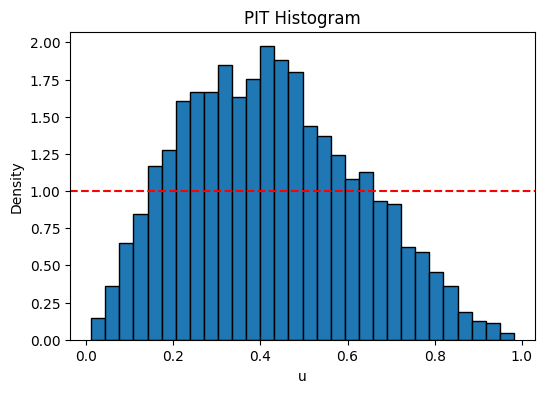

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pit, bins=30, density=True, edgecolor="k")
plt.axhline(1.0, color="red", linestyle="--")
plt.title("PIT Histogram")
plt.xlabel("u")
plt.ylabel("Density")
plt.show()

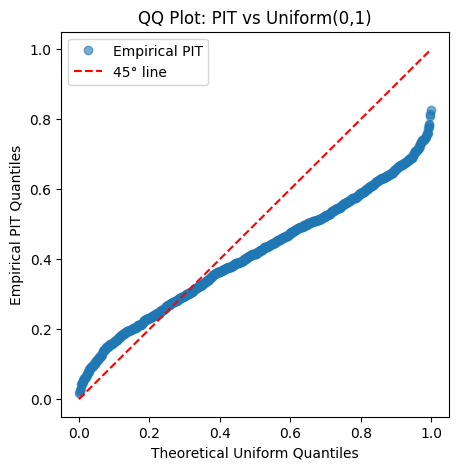

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# sort PITs
pit_sorted = np.sort(pit)

# theoretical quantiles of Uniform(0,1)
n = len(pit_sorted)
u_theoretical = (np.arange(1, n+1) - 0.5) / n

# QQ plot
plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1)")
plt.legend()
plt.show()

In [27]:
from scipy.stats import norm

# Quantile residuals
qr = norm.ppf(pit)

# Remove infinities if any (should not happen if PIT is clean)
qr = qr[np.isfinite(qr)]


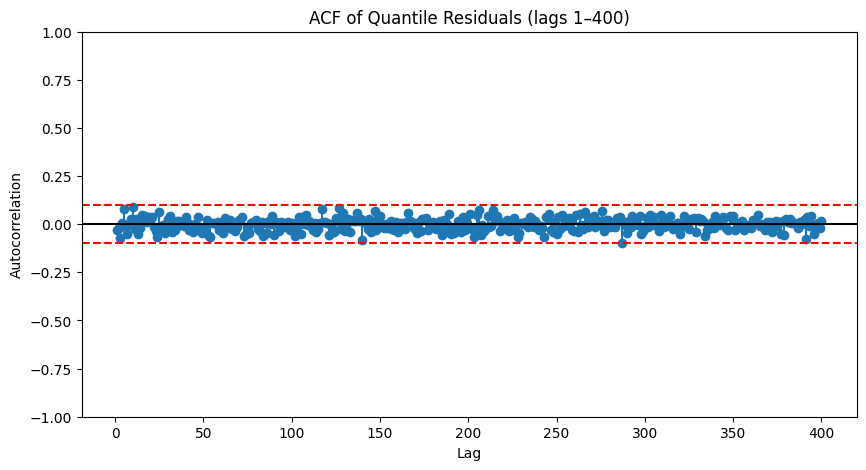

In [30]:
from statsmodels.tsa.stattools import acf

nlags = 400
acf_vals = acf(qr, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]     # drop lag 0
lags = np.arange(1, nlags+1)

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(0.1, color="red", linestyle="--")
plt.axhline(-0.1, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-1.0, 1.0))
plt.show()

## Zero augmented

In [39]:
import numpy as np

def iterate_zagb2(
    mu0,
    gamma0,
    gamma_star0,
    alpha,
    kappa_mu,
    c,
    kappa_gamma,
    delta_0,
    delta_1,
    gamma,
    xi,
    zeta,
    harmonics,
    period,
    T,
    y=None,
    mode="loglik"
):
    """
    GAS recursion with trigonometric seasonality
    and Zero-Augmented GB2 distribution.

    If mode == "loglik":
        returns -loglik (for optimizer)

    If mode == "filter":
        returns dict with states and scores
    """

    dist = ZAGB2LogLinkDistribution()

    # --- allocate ---
    mu = np.zeros(T + 1)
    phi = np.zeros(T)
    score = np.zeros(T)

    # safety clipping
    km = np.clip(kappa_mu, 1e-6, 1.0)
    kg = np.clip(kappa_gamma, 1e-6, 1.0)
    alpha = np.clip(alpha, 0.8, 0.999)

    gamma = np.clip(gamma, 0.5, 4.0)
    xi = np.clip(xi, 0.6, 3.0)
    zeta = np.clip(zeta, gamma + 0.2, 6.0)

    mu[0] = mu0
    gamma_ = gamma0.copy()
    gamma_star = gamma_star0.copy()

    loglik = 0.0

    # initial state
    phi[0] = mu[0] + np.sum(gamma_)

    for t in range(T):

        if t > 0:
            phi[t] = mu[t] + np.sum(gamma_)

        if not np.isfinite(phi[t]):
            return 1e12

        # ---------- LOG-LIKELIHOOD ----------
        if mode == "loglik":
            if y is None:
                raise ValueError("y must be provided when mode='loglik'")

            ll = dist.logpdf(
                y[t],
                delta_0=delta_0,
                delta_1=delta_1,
                phi=phi[t],
                gamma=gamma,
                xi=xi,
                zeta=zeta
            )

            if not np.isfinite(ll):
                return 1e12

            loglik += ll

        # ---------- SCORE ----------
        s = dist.score(
            y[t],
            delta_0=delta_0,
            delta_1=delta_1,
            phi=phi[t],
            gamma=gamma,
            xi=xi,
            zeta=zeta
        )

        score[t] = s[0]  # φ-score only

        # ---------- GAS μ UPDATE ----------
        mu[t + 1] = c + alpha * mu[t] + km * score[t]

        # ---------- TRIGONOMETRIC UPDATE ----------
        for j in range(harmonics):
            lam = 2 * np.pi * (j + 1) / period

            g_prev = gamma_[j]
            gs_prev = gamma_star[j]

            gamma_new = (
                np.cos(lam) * g_prev
                + np.sin(lam) * gs_prev
                + kg * score[t]
            )

            gamma_star_new = (
                np.cos(lam) * gs_prev
                - np.sin(lam) * g_prev
                + kg * score[t]
            )

            gamma_[j] = gamma_new
            gamma_star[j] = gamma_star_new

    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "mu": mu[:-1],
            "gamma": gamma_,
            "gamma_star": gamma_star,
            "score": score,
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [40]:
def objective_zagb2(theta, y, harmonics=10, period=365):

    mu0, c, alpha, kappa_mu, kappa_gamma, delta_0, delta_1, gamma, xi, zeta = theta

    T = len(y)
    gamma0 = np.zeros(harmonics)
    gamma_star0 = np.zeros(harmonics)

    return iterate_zagb2(
        mu0=mu0,
        gamma0=gamma0,
        gamma_star0=gamma_star0,
        alpha=alpha,
        kappa_mu=kappa_mu,
        c=c,
        kappa_gamma=kappa_gamma,
        delta_0=delta_0,
        delta_1=delta_1,
        gamma=gamma,
        xi=xi,
        zeta=zeta,
        harmonics=harmonics,
        period=period,
        T=T,
        y=y,
        mode="loglik"
    )


In [41]:
import pandas as pd
import numpy as np

xls = pd.read_csv("data/precipitation.csv")
xls = xls.tail(730)

# assume precipitation column is the first or named, adapt if needed
y_raw = xls.iloc[:, 0].values.astype(float)

# clean
y = np.nan_to_num(y_raw, nan=0.0, posinf=0.0, neginf=0.0)

print("Zeros:", np.mean(y == 0))
print("Max:", y.max())
print("Mean:", y.mean())


Zeros: 0.6520547945205479
Max: 75.0
Mean: 3.2800000000000002


In [42]:
harmonics = 10
period = 365

theta0 = np.array([
    np.log(np.mean(y[y > 0]) + 1e-3),  # mu0 (scale from positives)
    0.0,                               # c
    0.97,                              # alpha
    0.01,                              # kappa_mu
    0.01,                              # kappa_gamma
    np.log(np.mean(y == 0) + 1e-3),    # delta_0 → initial zero prob
    -0.5,                              # delta_1 (weak dependence on phi)
    1.2,                               # gamma
    1.2,                               # xi
    3.0                                # zeta
])


In [43]:
bounds = [
    (-1.5, 3.0),      # mu0
    (-0.1, 0.1),      # c
    (0.90, 0.995),    # alpha
    (1e-4, 0.05),     # kappa_mu
    (1e-4, 0.05),     # kappa_gamma
    (-5.0, 2.0),      # delta_0
    (-2.0, 2.0),      # delta_1
    (0.7, 2.5),       # gamma
    (0.7, 2.0),       # xi
    (2.0, 6.0)        # zeta > gamma
]


In [44]:
from scipy.optimize import minimize

res = minimize(
    objective_zagb2,
    theta0,
    args=(y, harmonics, period),
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "disp": True,
        "maxiter": 500,
        "gtol": 1e-4,
        "ftol": 1e-6
    }
)


C:\Users\ilang\AppData\Local\Temp\ipykernel_46960\361529701.py:3: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


In [45]:
dist = ZAGB2LogLinkDistribution()

pit = np.array([
    dist.cdf(
        y[t],
        delta_0=res.x[5],
        delta_1=res.x[6],
        phi=phi_hat[t],
        gamma=res.x[7],
        xi=res.x[8],
        zeta=res.x[9]
    )
    for t in range(len(y))
])


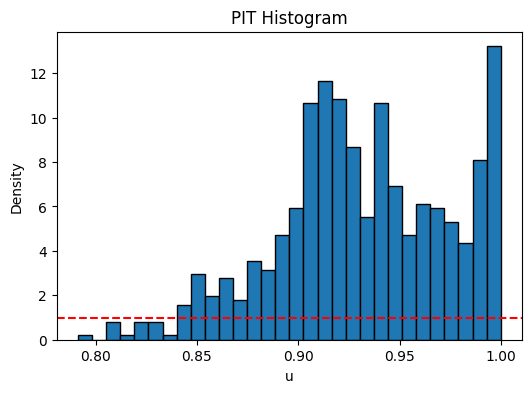

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pit, bins=30, density=True, edgecolor="k")
plt.axhline(1.0, color="red", linestyle="--")
plt.title("PIT Histogram")
plt.xlabel("u")
plt.ylabel("Density")
plt.show()

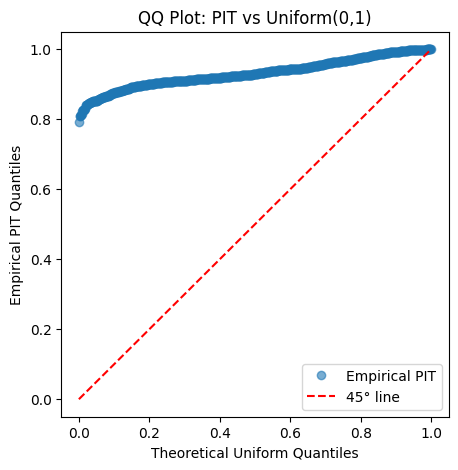

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# sort PITs
pit_sorted = np.sort(pit)

# theoretical quantiles of Uniform(0,1)
n = len(pit_sorted)
u_theoretical = (np.arange(1, n+1) - 0.5) / n

# QQ plot
plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1)")
plt.legend()
plt.show()

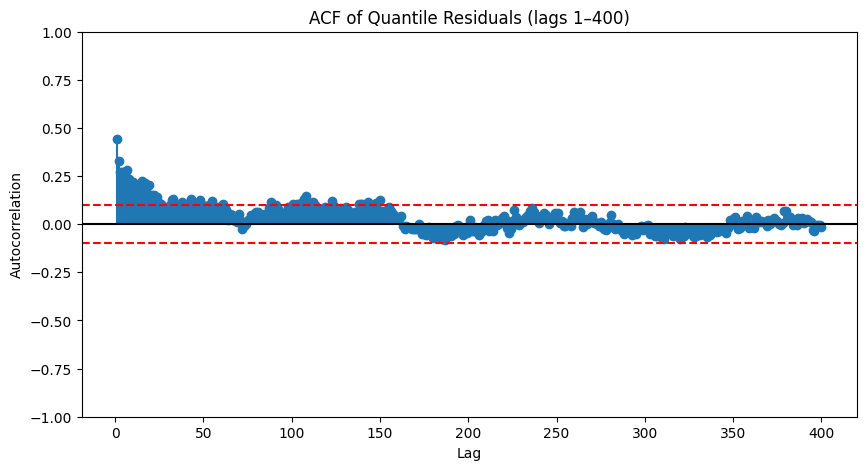

In [49]:
from scipy.stats import norm

# Quantile residuals
qr = norm.ppf(pit)

# Remove infinities if any (should not happen if PIT is clean)
qr = qr[np.isfinite(qr)]

from statsmodels.tsa.stattools import acf

nlags = 400
acf_vals = acf(qr, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]     # drop lag 0
lags = np.arange(1, nlags+1)

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(0.1, color="red", linestyle="--")
plt.axhline(-0.1, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-1.0, 1.0))
plt.show()